In [19]:
from google.colab import files
train_data = files.upload()

Saving ISIC_0024312.jpg to ISIC_0024312.jpg


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import color
from skfuzzy.cluster import cmeans

In [21]:
pip install -U scikit-fuzzy

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


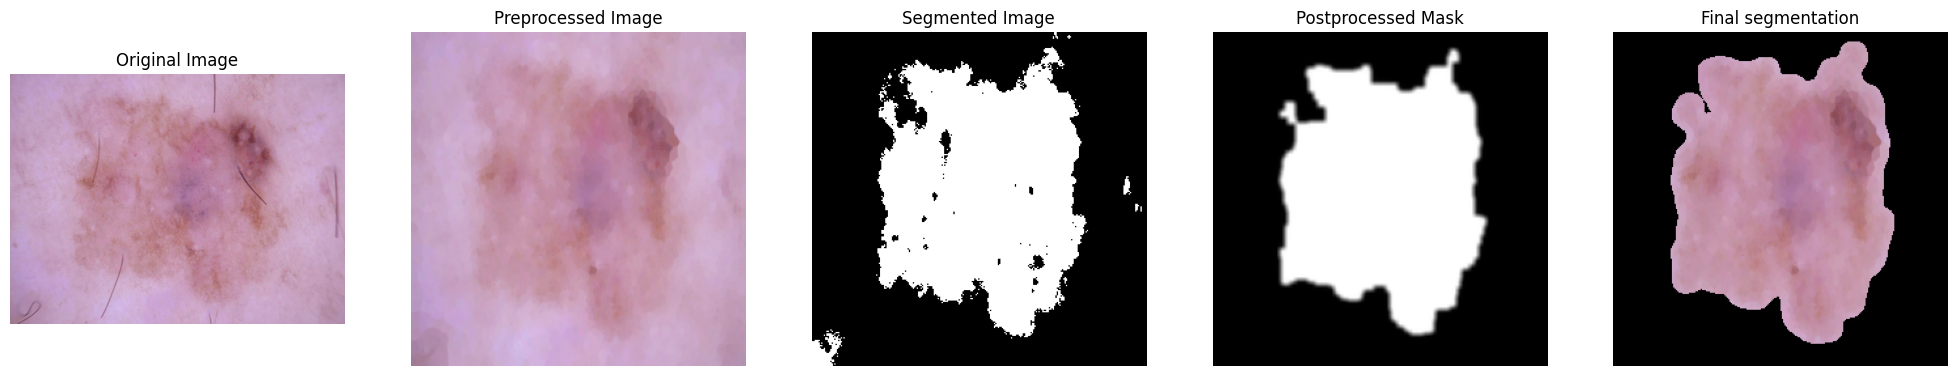

ISIC_0024306_segmented.jpg


In [ ]:
def preprocess_image(image_path, lowbound=20, filterstruc=3, inpaintmat=3): 
    img = cv2.imread(image_path) 
 
    img_log = np.log1p(np.float32(img)) 
    M, N, _ = img.shape 
    sigma = 25 
    [x, y] = np.meshgrid(np.linspace(-1, 1, N), np.linspace(-1, 1, M)) 
    z = np.sqrt(x**2 + y**2) 
    mask = np.exp(-((z - 0.5)**2) / (2 * sigma**2)) 
    mask = np.dstack((mask, mask, mask)) 
    img_log_filt = np.fft.fftshift(np.fft.fft2(img_log)) * mask 
    img_corr = np.real(np.fft.ifft2(np.fft.ifftshift(img_log_filt))) 
    img_corr = np.expm1(np.clip(img_corr, 0, None)).astype(np.uint8) 
 
    lab = cv2.cvtColor(img_corr, cv2.COLOR_BGR2LAB) 
    l, a, b = cv2.split(lab) 
    clahe = cv2.createCLAHE(clipLimit=4, tileGridSize=(8, 8)) 
    cl = clahe.apply(l) 
    limg = cv2.merge((cl, a, b)) 
    enhanced_img = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR) 
 
    gray = cv2.cvtColor(enhanced_img, cv2.COLOR_BGR2GRAY) 
 
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11)) 
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel) 
 
    bhg = cv2.GaussianBlur(blackhat, (5, 5), cv2.BORDER_DEFAULT) 
 
    mask = cv2.adaptiveThreshold(bhg, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2) 
 
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)) 
    mask = cv2.dilate(mask, kernel, iterations=1) 
 
    dst = cv2.inpaint(img, mask, inpaintmat, cv2.INPAINT_TELEA) 
 
    dst = cv2.resize(dst, (img.shape[1], img.shape[0])) 
 
    return dst 
 
for i in range(24306, 24316):
  path = 'ISIC_0024312.jpg'#path = f'ISIC_00{i}.jpg'  
  img = cv2.imread(path) 
  image = preprocess_image(path) 
  pre = image 
  img = cv2.resize(img, (256,256), interpolation=cv2.INTER_CUBIC)
  pre = cv2.resize(pre, (256,256), interpolation=cv2.INTER_CUBIC)
  image = cv2.resize(image, (256,256), interpolation=cv2.INTER_CUBIC)
  lab_image = color.rgb2lab(image) 
  
  X = np.reshape(lab_image, (-1, 3)) 
  
  X = np.reshape(lab_image, (-1, 3)) 
  
  n_clusters = 2 
  fuzziness = 2 
  cntr, u, _, _, _, _, _ = cmeans(X.T, n_clusters, fuzziness, error=0.005, maxiter=1000) 
  
  labels = np.argmax(u, axis=0)

  average_intensity = np.zeros(n_clusters)
  for b in range(n_clusters):
      average_intensity[b] = np.mean(X[labels == b, 0])  

  infected_cluster = np.argmin(average_intensity)
  healthy_cluster = np.argmax(average_intensity)

  segmented = np.reshape(labels, (img.shape[:2]))
  labels1 = segmented
  segmented = np.uint8(segmented == infected_cluster) * 255
  
  ss = segmented
  kernel = np.ones((5, 5), np.uint8) 
  mask = cv2.morphologyEx(segmented, cv2.MORPH_OPEN, kernel) 
  kernel = np.ones((9, 9), np.uint8) 
  mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel) 
  
  num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask) 
  min_size = 1000 
  for w in range(1, num_labels): 
      if stats[w, cv2.CC_STAT_AREA] < min_size: 
          mask[labels == w] = 0 
  contours, hierarchy = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE) 
  for contour in contours: 
      area = cv2.contourArea(contour) 
      if area < 1000: 
          cv2.drawContours(mask, [contour], 0, 0, -1) 
      else: 
          perimeter = cv2.arcLength(contour, True) 
          approx = cv2.approxPolyDP(contour, 0.01 * perimeter, True) 
          if len(approx) == 4: 
              cv2.drawContours(mask, [contour], 0, 1, -1) 
              cv2.drawContours(pre, [contour], 0, (0, 255, 0), thickness=2)

  mask_smooth = cv2.bilateralFilter(mask.astype(np.float32), 15, 100, 100)
  mask_smooth = mask_smooth.astype(np.uint8)
  mask = mask_smooth
  mask = cv2.GaussianBlur(mask.astype(np.float32), (5, 5), 2) 
  img = cv2.imread(path) 
  
  bool_mask = mask.astype(np.bool_) 
  final = bool_mask[..., np.newaxis]*pre 

  fig, axs = plt.subplots(1, 5, figsize=(25, 5)) 
  axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) 
  axs[0].set_title('Original Image') 
  axs[0].axis('off') 
  axs[1].imshow(cv2.cvtColor(pre, cv2.COLOR_BGR2RGB)) 
  axs[1].set_title('Preprocessed Image') 
  axs[1].axis('off') 
  
  axs[2].imshow(cv2.cvtColor(ss, cv2.COLOR_BGR2RGB)) 
  axs[2].set_title('Segmented Image') 
  axs[2].axis('off') 
  
  axs[3].imshow(mask, cmap='gray') 
  axs[3].set_title('Postprocessed Mask') 
  axs[3].axis('off') 
  
  
  axs[4].imshow(cv2.cvtColor(final, cv2.COLOR_BGR2RGB)) 
  axs[4].set_title('Final segmentation') 
  axs[4].axis('off') 
  
  plt.show()

  cv2.imwrite( f'ISIC_00{i}_segmented.jpg' , final)
  print( f'ISIC_00{i}_segmented.jpg' )
  break

In [ ]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
from skimage import color
import matplotlib.pyplot as plt

def preprocess_image(image_path, lowbound=20, filterstruc=3, inpaintmat=3): 
    img = cv2.imread(image_path) 
 
    img_log = np.log1p(np.float32(img)) 
    M, N, _ = img.shape 
    sigma = 25 
    [x, y] = np.meshgrid(np.linspace(-1, 1, N), np.linspace(-1, 1, M)) 
    z = np.sqrt(x**2 + y**2) 
    mask = np.exp(-((z - 0.5)**2) / (2 * sigma**2)) 
    mask = np.dstack((mask, mask, mask)) 
    img_log_filt = np.fft.fftshift(np.fft.fft2(img_log)) * mask 
    img_corr = np.real(np.fft.ifft2(np.fft.ifftshift(img_log_filt))) 
    img_corr = np.expm1(np.clip(img_corr, 0, None)).astype(np.uint8) 
 
    lab = cv2.cvtColor(img_corr, cv2.COLOR_BGR2LAB) 
    l, a, b = cv2.split(lab) 
    clahe = cv2.createCLAHE(clipLimit=4, tileGridSize=(8, 8)) 
    cl = clahe.apply(l) 
    limg = cv2.merge((cl, a, b)) 
    enhanced_img = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR) 
 
    gray = cv2.cvtColor(enhanced_img, cv2.COLOR_BGR2GRAY) 
 
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11)) 
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel) 
 
    bhg = cv2.GaussianBlur(blackhat, (5, 5), cv2.BORDER_DEFAULT) 
 
    mask = cv2.adaptiveThreshold(bhg, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2) 
 
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)) 
    mask = cv2.dilate(mask, kernel, iterations=1) 
 
    dst = cv2.inpaint(img, mask, inpaintmat, cv2.INPAINT_TELEA) 

    lab_img = cv2.cvtColor(dst, cv2.COLOR_BGR2LAB)
    lab_img = lab_img.reshape((-1, 3))

    kmeans = KMeans(n_clusters=5, random_state=42).fit(lab_img)
    labels = kmeans.labels_
    centers = kmeans.cluster_centers_

    labels = np.reshape(labels, (img.shape[0], img.shape[1]))

    plt.imshow(labels)
    plt.show()

    centers = np.reshape(centers, (5, 1, 3))

    rgb_centers = color.lab2rgb(centers)

    plt.imshow(rgb_centers)
    plt.show()

    return dst